**Table of contents**<a id='toc0_'></a>    
- [Photoswiching fingerprints of 4 fluorophores](#toc1_)    
  - [Figure](#toc1_1_)    
  - [Reading data](#toc1_2_)    
      - [4 fluorophores](#toc1_2_1_1_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Photoswiching fingerprints of 4 fluorophores](#toc0_)

In [1]:
import glob
import os

import numpy as np
import pandas as pd
from matplotlib import rcParams

import fluopy.figure as fi
import fluopy.routines as rt

%load_ext autoreload
%autoreload 2

import warnings


def custom_warning_format(msg, category, filename, lineno, line=None):
    if line is None:
        import linecache

        line = linecache.getline(filename, lineno)
    return f"WARNING for line: {line} {msg} \n"


warnings.formatwarning = custom_warning_format

reading_from = r"D:\python_output\Chapter_I\0_4_multi_f_PFA\Neuer Ordner"
rng = np.random.default_rng(1)

## <a id='toc1_1_'></a>[Figure](#toc0_)

In [ ]:
red = "#D55E00"
sky_blue = "#56B4E9"
green = "#009E73"
orange = "#E69F00"
colors = [red, sky_blue, green, orange]


def plot_figure3(
    ax,
    labels,
    data,
    legendtitle,
    xlim2,
    ylim2,
    spacing2,
    inset_x_ticks,
    colors=colors,
    num_f=2,
):
    markers = ["o", "s", "D", "^"]
    spacing1 = 20000
    description = dict(
        ylabel="Cumulative prob.",
        xlabel="Photon arrival time (s)",
        legend=True,
        xlim=[-10, 300],
        ylim=[0, 1.1],
    )
    for fingerprint, label, color, marker in zip(data, labels, colors, markers):
        fi.universal_figure(
            data=[fingerprint.index[::spacing1], fingerprint[::spacing1]],
            label=label,
            color=color,
            marker=marker,
            linestyle="",
            axes=ax,
        )
    fi.universal_figure(
        axes=ax,
        legendargs=dict(
            title=legendtitle,
            framealpha=1,
            edgecolor="black",
            fancybox=False,
            title_fontsize=15,
        ),
        **description,
    )

    inset = ax.inset_axes([0.51, 0.2, 0.2, 0.2], xlim=(0, xlim2), ylim=(0, ylim2))
    for fingerprint, label, color, marker in zip(data, labels, colors, markers):
        fi.universal_figure(
            data=[fingerprint.index[::spacing2], fingerprint[::spacing2]],
            axes=inset,
            label=label,
            color=color,
            marker=marker,
            linestyle="",
        )
    inset.set_ylabel("")
    inset.set_xlabel("")
    inset.set_xticks(inset_x_ticks)


rcParams["axes.linewidth"] = 2

## <a id='toc1_2_'></a>[Reading data](#toc0_)

#### <a id='toc1_2_1_1_'></a>[4 fluorophores](#toc0_)

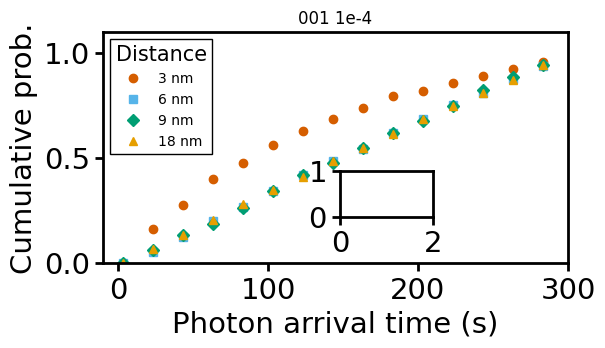

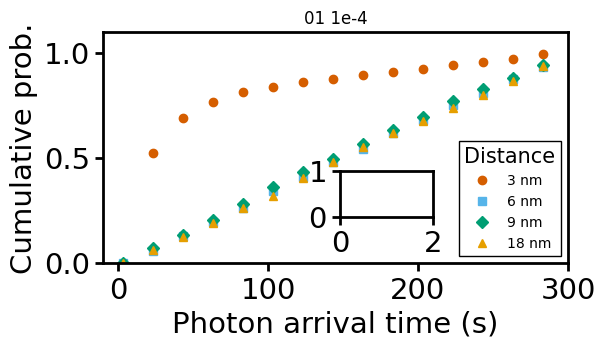

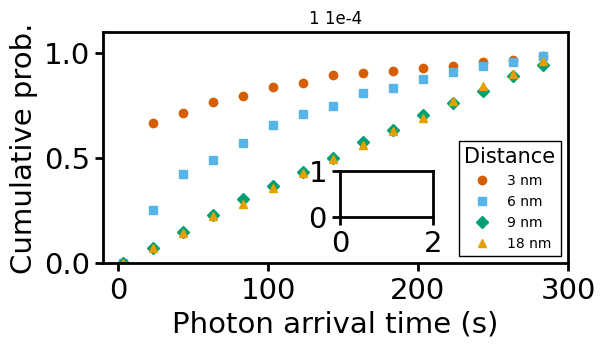

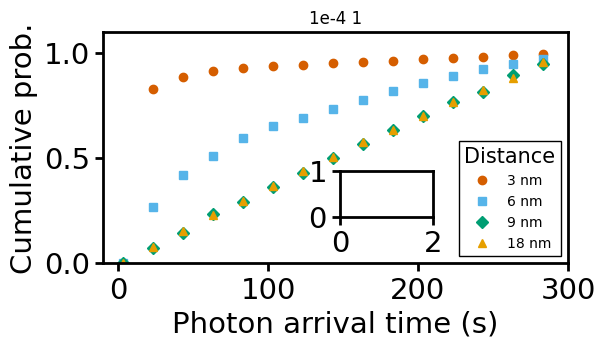

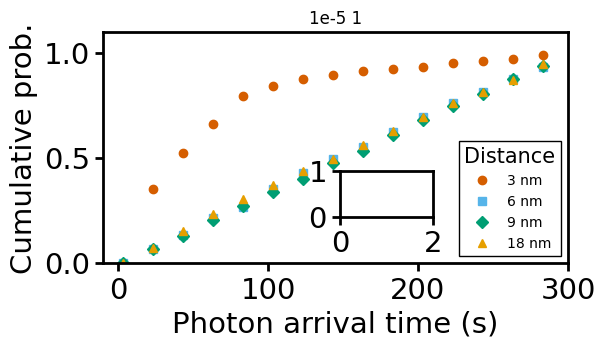

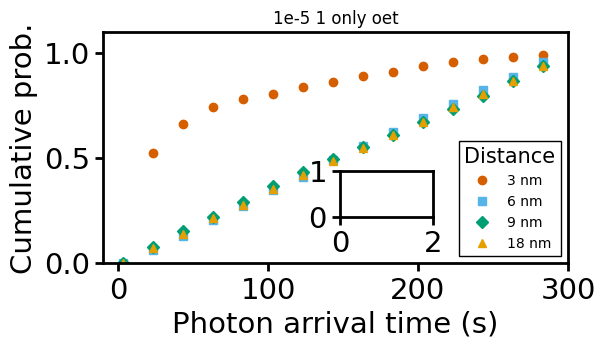

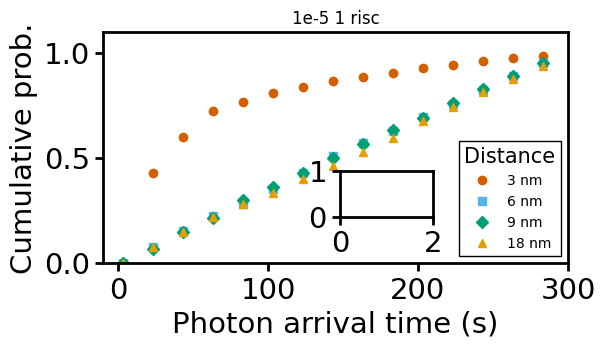

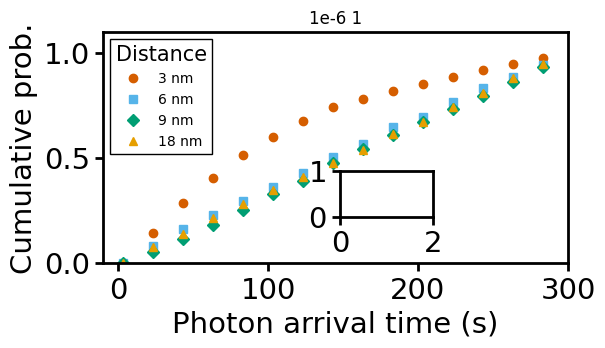

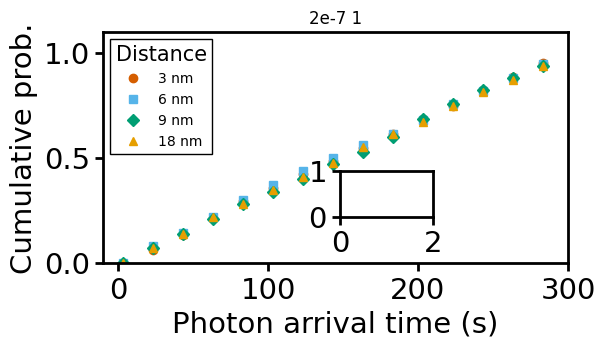

In [6]:
identifiers = [
    "3nm",
    "6nm",
    "9nm",
    "18nm",
]
for folder in os.listdir(reading_from):
    folder_path = os.path.join(reading_from, folder)
    target_path = os.path.join(folder_path, "4F")

    fingerprints_all = []
    for i, id in enumerate(identifiers):
        fingerprints_all.append(
            pd.Series(
                np.zeros(300001),
                np.round(np.linspace(0, 300, 300001), decimals=12),
                dtype=np.int32,
            )
        )
        for file in glob.glob(target_path + "/*"):
            if file.endswith(".parquet") and id in file:
                data = pd.read_parquet(file)
                non_zero = data[data > 0].values.flatten()
                non_zero = non_zero[~np.isnan(non_zero)]
                fingerprints_all[i] += data.sum(axis=1)
        fingerprint = fingerprints_all[i].cumsum() / fingerprints_all[i].sum()
        fingerprint = rt.truncate_fingerprints(fingerprint, 3000, 300000)
        fingerprints_all[i] = fingerprint

    labels1 = ["3 nm", "6 nm", "9 nm", "18 nm"]
    legendtitle1 = "Distance"
    ax = fi.universal_figure()[0][0]
    plot_figure3(
        ax,
        labels1,
        fingerprints_all,
        legendtitle1,
        2,
        1,
        400,
        [0, 2],
        num_f=2,
    )
    ax.set_title(folder)

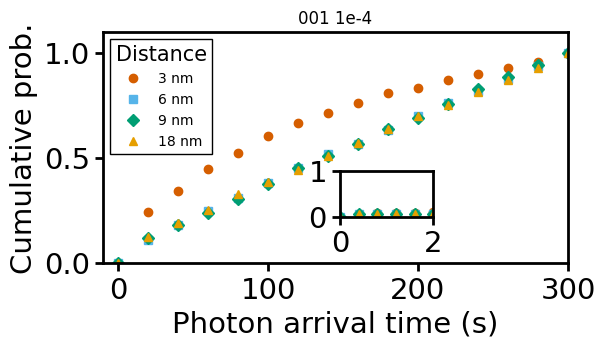

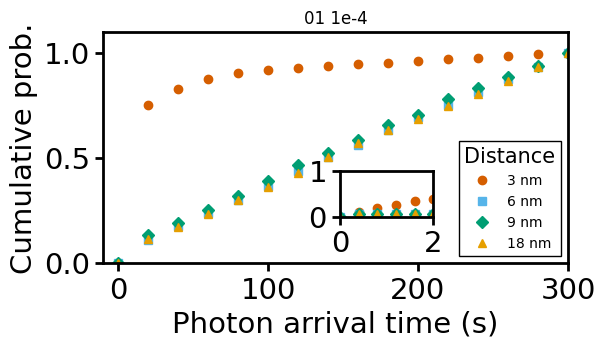

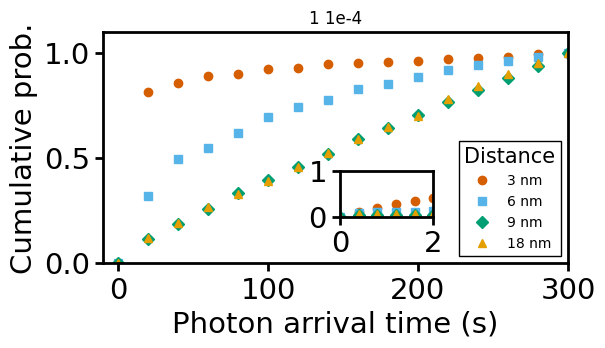

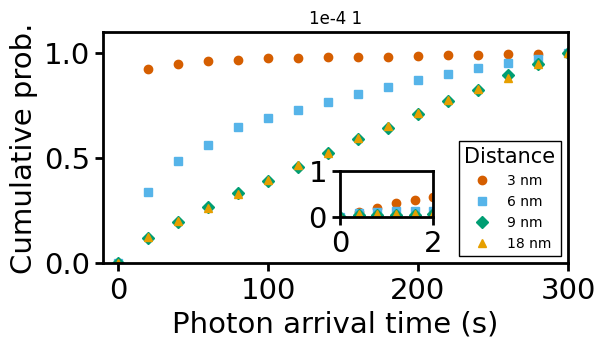

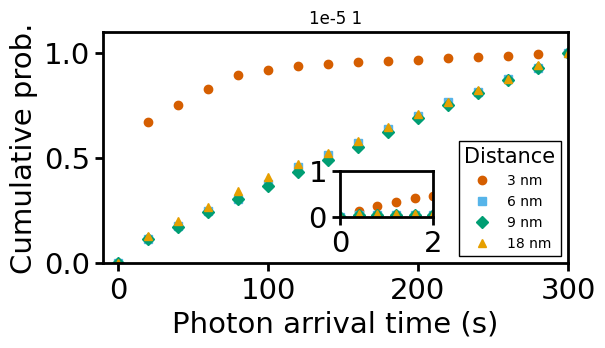

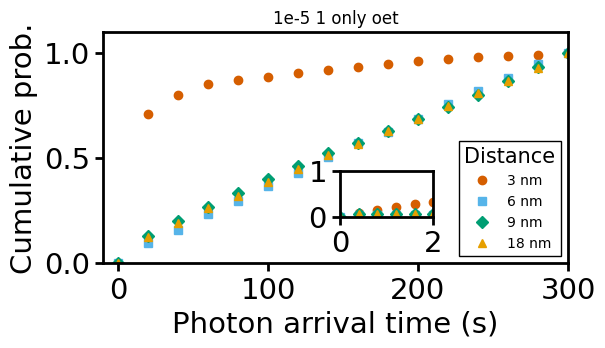

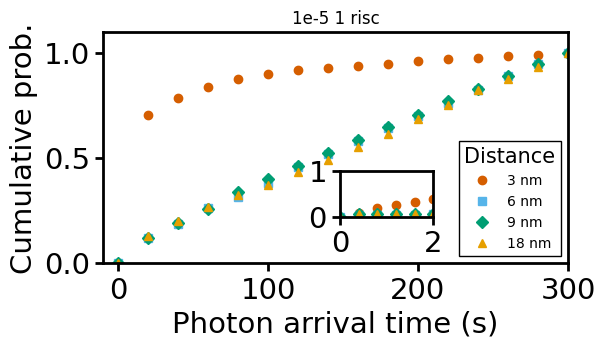

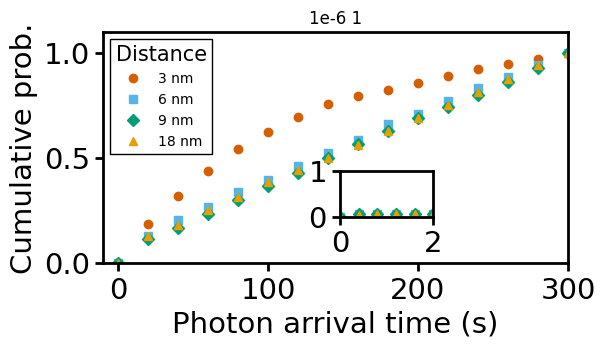

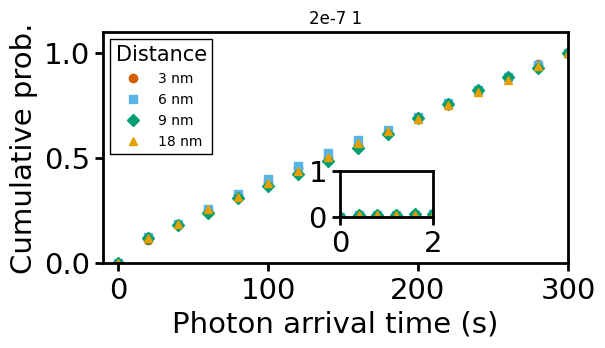

In [3]:
identifiers = [
    "3nm",
    "6nm",
    "9nm",
    "18nm",
]
for folder in os.listdir(reading_from):
    folder_path = os.path.join(reading_from, folder)
    target_path = os.path.join(folder_path, "4F")

    fingerprints_all = []
    for i, id in enumerate(identifiers):
        fingerprints_all.append(
            pd.Series(
                np.zeros(300001),
                np.round(np.linspace(0, 300, 300001), decimals=12),
                dtype=np.int32,
            )
        )
        for file in glob.glob(target_path + "/*"):
            if file.endswith(".parquet") and id in file:
                data = pd.read_parquet(file)
                non_zero = data[data > 0].values.flatten()
                non_zero = non_zero[~np.isnan(non_zero)]
                fingerprints_all[i] += data.sum(axis=1)
        fingerprint = fingerprints_all[i].cumsum() / fingerprints_all[i].sum()
        fingerprints_all[i] = fingerprint

    labels1 = ["3 nm", "6 nm", "9 nm", "18 nm"]
    legendtitle1 = "Distance"
    ax = fi.universal_figure()[0][0]
    plot_figure3(
        ax,
        labels1,
        fingerprints_all,
        legendtitle1,
        2,
        1,
        400,
        [0, 2],
        num_f=2,
    )
    ax.set_title(folder)